In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from gan_data_gen import load_data_for_wgan, get_mean_std_error
from wgan import compare_dfs
import numpy as np

In [2]:
maxepochs_range = [2000, 3000, 4000, 5000]
dropout_range = [0., 0.1, 0.2, 0.3]
batchsize = 256
lr = 1e-3

hparams = {}
for maxepochs in maxepochs_range:
        for dropout in dropout_range:
            df_synthetic = pd.read_parquet(f'data/synthetic-maxepochs={maxepochs}_lr={lr}_batchsize={batchsize}_dropout={dropout}_n=20000.parquet')
            df_train, _ = load_data_for_wgan('data/train.parquet')
            df_synthetic = df_synthetic[df_train.columns].iloc[:len(df_train)]

            mean_rmse, std_rmse = get_mean_std_error(df_train, df_synthetic[df_train.columns].iloc[:len(df_train)] )
            hparams[(maxepochs, dropout)] = (mean_rmse, std_rmse)

/home/users/rsahoo/zfs/gsb/intermediate-yens/rsahoo/poverty/dup/lib/python3.10/site-packages/wgan/wgan.py:66: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at ../aten/src/ATen/native/ReduceOps.cpp:1823.)
  self.stds  = [x.std(0,  keepdim=True) + 1e-5 for x in (continuous, context)]
/home/users/rsahoo/zfs/gsb/intermediate-yens/rsahoo/poverty/dup/lib/python3.10/site-packages/wgan/wgan.py:66: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at ../aten/src/ATen/native/ReduceOps.cpp:1823.)
  self.stds  = [x.std(0,  keepdim=True) + 1e-5 for x in (continuous, context)]
/home/users/rsahoo/zfs/gsb/intermediate-yens/rsahoo/poverty/dup/lib/python3.10/site-packages/wgan/wgan.py:66: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictl

In [3]:
df_synthetic = pd.read_parquet(f'data/synthetic-maxepochs=3000_lr=0.001_batchsize=256_dropout=0.2_n=20000.parquet')
df_train, _ = load_data_for_wgan('data/train.parquet')
df_synthetic = df_synthetic[df_train.columns].iloc[:len(df_train)]

/home/users/rsahoo/zfs/gsb/intermediate-yens/rsahoo/poverty/dup/lib/python3.10/site-packages/wgan/wgan.py:66: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at ../aten/src/ATen/native/ReduceOps.cpp:1823.)
  self.stds  = [x.std(0,  keepdim=True) + 1e-5 for x in (continuous, context)]


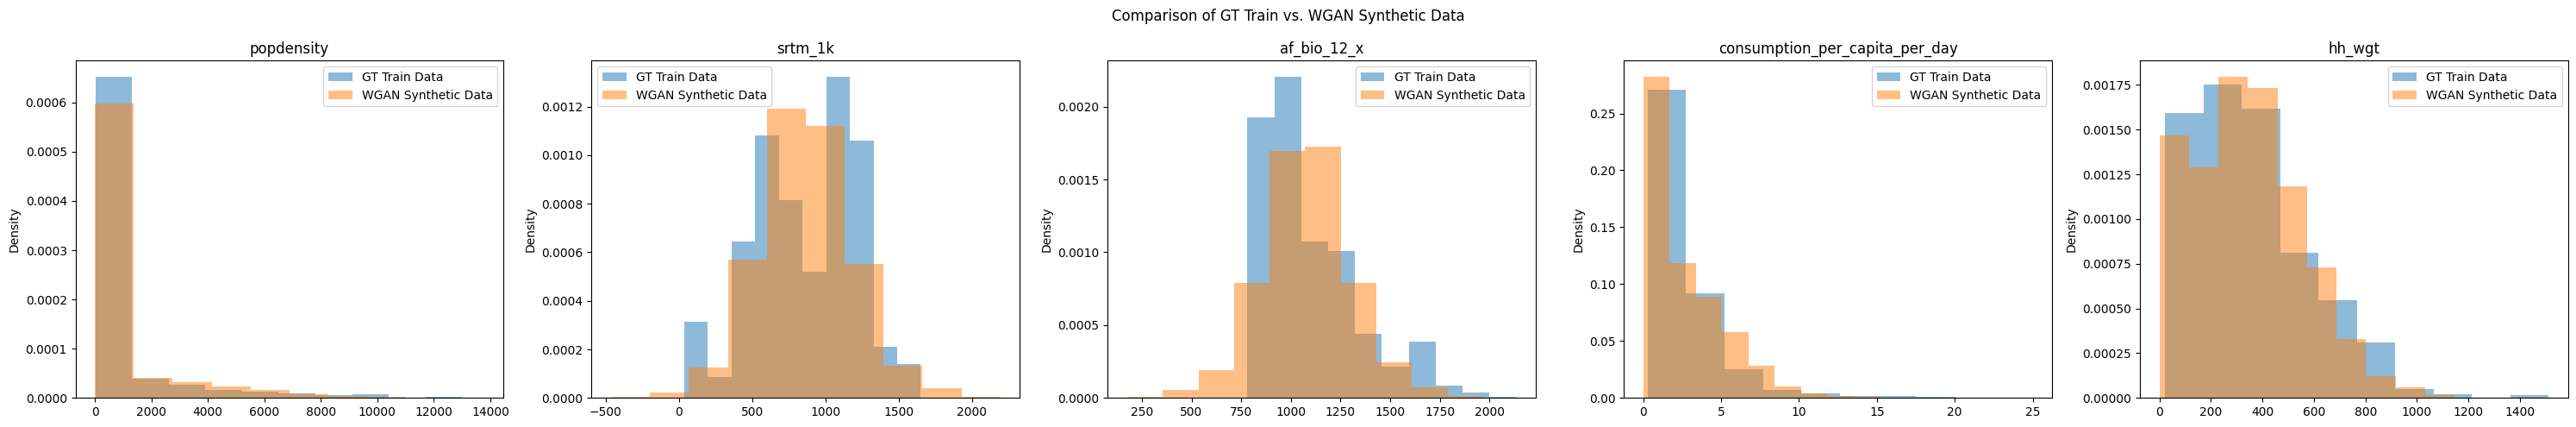

In [12]:
fig, axs = plt.subplots(1, 5, figsize=(30, 5))

features = ['popdensity', 'srtm_1k', 'af_bio_12_x', 'consumption_per_capita_per_day', 'hh_wgt']

plt.suptitle('Comparison of GT Train vs. WGAN Synthetic Data')

for i, feature in enumerate(features):
    if feature == 'consumption_per_capita_per_day':
        axs[i].hist(np.clip(df_train[feature], 0., 25.), alpha=0.5, label='GT Train Data', density=True)
    else:
        axs[i].hist(df_train[feature], alpha=0.5, label='GT Train Data', density=True)
    axs[i].hist(df_synthetic[feature], alpha=0.5, label='WGAN Synthetic Data', density=True)
    axs[i].set_title(feature)
    axs[i].set_ylabel('Density')
    axs[i].legend()
plt.tight_layout()
plt.savefig("figs/wgan.pdf")

